## Objective:
This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.

### Dataset:
Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.


## Tasks:

1.Handle missing values as per the best practices (imputation, removal, etc.).

●	Apply scaling techniques to numerical features:

 a.	Standard Scaling   b. Min-Max Scaling

●	Discuss the scenarios where each scaling technique is preferred and why.


## Step 1: Load and Explore Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from scipy import stats

# Load the dataset
df = pd.read_csv('adult_with_headers (1).csv')

# Basic exploration
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (32561, 15)

First 5 rows:
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174           

## Step 2: Handle Missing Values


In [16]:
# Replace '?' with NaN
df_clean = df.replace('?', np.nan)

# Check missing values
print("Missing values after replacing '?':")
print(df_clean.isnull().sum())

# Calculate missing percentage
missing_pct = df_clean.isnull().sum() / len(df_clean) * 100
print("\nMissing percentage:")
print(missing_pct[missing_pct > 0])

# Remove rows with missing values in critical columns
df_clean = df_clean.dropna()

print(f"\nShape after removing missing values: {df_clean.shape}")

Missing values after replacing '?':
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Missing percentage:
Series([], dtype: float64)

Shape after removing missing values: (32561, 15)


## Step 3: Apply Scaling Techniques

In [17]:
# Identify numerical columns
numerical_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 
                  'capital_loss', 'hours_per_week']

# Extract numerical data
numerical_data = df_clean[numerical_cols].astype(float)

# Standard Scaling
scaler_standard = StandardScaler()
standard_scaled = scaler_standard.fit_transform(numerical_data)

# Min-Max Scaling
scaler_minmax = MinMaxScaler()
minmax_scaled = scaler_minmax.fit_transform(numerical_data)

# Create DataFrames for comparison
df_standard = pd.DataFrame(standard_scaled, columns=numerical_cols)
df_minmax = pd.DataFrame(minmax_scaled, columns=numerical_cols)

print("Standard Scaling Results:")
print(df_standard.describe())
print("\nMin-Max Scaling Results:")
print(df_minmax.describe())

Standard Scaling Results:
                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  3.256100e+04  3.256100e+04   3.256100e+04  3.256100e+04  3.256100e+04   
mean  -2.662271e-17 -9.732565e-17   1.479525e-16  5.237255e-18 -4.364379e-17   
std    1.000015e+00  1.000015e+00   1.000015e+00  1.000015e+00  1.000015e+00   
min   -1.582206e+00 -1.681631e+00  -3.529656e+00 -1.459205e-01 -2.166595e-01   
25%   -7.757679e-01 -6.816910e-01  -4.200596e-01 -1.459205e-01 -2.166595e-01   
50%   -1.159546e-01 -1.082193e-01  -3.136003e-02 -1.459205e-01 -2.166595e-01   
75%    6.904838e-01  4.478765e-01   7.460392e-01 -1.459205e-01 -2.166595e-01   
max    3.769612e+00  1.226856e+01   2.300838e+00  1.339458e+01  1.059351e+01   

       hours_per_week  
count    3.256100e+04  
mean    -2.574984e-17  
std      1.000015e+00  
min     -3.194030e+00  
25%     -3.542945e-02  
50%     -3.542945e-02  
75%      3.695194e-01  
max      4.742967e+00  

Min-Max Scaling Results:
           

### Discussion: When to use each scaling technique
Standard Scaling (Z-score normalization):

Preferred when: Data follows a Gaussian/normal distribution, or when using algorithms that assume normally distributed data (e.g., Linear Regression, Logistic Regression, SVM, PCA)

Why: It centers data around mean=0 and std=1, which is crucial for algorithms sensitive to feature scales and those that compute distances

Min-Max Scaling:

Preferred when: Data is not normally distributed, or when using algorithms that don't assume any distribution (e.g., Neural Networks, KNN, K-Means)

Why: It preserves the original distribution shape and bounds values to [0,1], which is useful for algorithms that require bounded inputs

# 2. Encoding Techniques:

●	Apply One-Hot Encoding to categorical variables with less than 5 categories.

●	Use Label Encoding for categorical variables. Data Exploration and Preprocessing:

●	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).

●	les with more than 5 categories.

●	Discuss the pros and cons of One-Hot Encoding and Label Encoding.


## Step 1: Identify Categorical Variables

In [7]:
# Identify categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols.tolist())

# Count categories for each categorical column
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")

Categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']
workclass: 9 unique values
education: 16 unique values
marital_status: 7 unique values
occupation: 15 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native_country: 42 unique values
income: 2 unique values


## Step 2: Apply One-Hot Encoding


In [8]:
# One-Hot Encoding for variables with less than 5 categories
low_cardinality_cols = [col for col in categorical_cols 
                        if df_clean[col].nunique() < 5 and col != 'income']

print("Low cardinality columns (for One-Hot):", low_cardinality_cols)

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=low_cardinality_cols, drop_first=True)
print(f"Shape after One-Hot Encoding: {df_encoded.shape}")

Low cardinality columns (for One-Hot): ['sex']
Shape after One-Hot Encoding: (32561, 15)


## 3. Feature Engineering:

●	Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.

●	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.


## Step 3: Apply Label Encoding

In [14]:
# Label Encoding for remaining categorical variables
high_cardinality_cols = [col for col in categorical_cols 
                         if col not in low_cardinality_cols and col != 'income']

# Also encode target variable
label_encoders = {}

# Encode features
for col in high_cardinality_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Encode target variable
le_target = LabelEncoder()
df_encoded['income'] = le_target.fit_transform(df_clean['income'])
print(f"Target encoding: 0={le_target.classes_[0]}, 1={le_target.classes_[1]}")

print(f"\nFinal shape after all encoding: {df_encoded.shape}")

Target encoding: 0= <=50K, 1= >50K

Final shape after all encoding: (32561, 15)


In [ ]:
Discussion: Pros and Cons of Encoding Techniques

One-Hot Encoding:

Pros	                                                                         Cons

1 No ordinal assumption (treats categories equally)                               1 Creates many new features (curse of dimensionality)
2 Works well with linear models                                                   2 Can cause multicollinearity
3 No information loss between categories                                          3 Memory intensive for high cardinality


Label Encoding:

Pros	                                                                         Cons

1 Maintains low dimensionality	                                                 1 Implies ordinal relationship (1 > 0, etc.)
2 Memory efficient	                                                             2 Can mislead models into thinking categories have order
3 Works well for tree-based models	                                             3 May not capture categorical relationships well


# 3. Feature Engineering:

●	Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.

●	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice


## Create 2 New Features


In [11]:
# Feature 1: Age Group (binned age)
# Rationale: Age often has non-linear relationship with income
df_clean['age_group'] = pd.cut(df_clean['age'], 
                                bins=[0, 25, 35, 45, 55, 65, 100],
                                labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])

# Feature 2: Capital Gain/Loss Ratio
# Rationale: The relationship between gains and losses might be more informative than absolute values
# Add small epsilon to avoid division by zero
df_clean['capital_ratio'] = (df_clean['capital_gain'] + 1) / (df_clean['capital_loss'] + 1)

# Feature 3: Total Capital Impact (combining gain and loss)
# Rationale: Net capital effect might better predict income
df_clean['total_capital_impact'] = df_clean['capital_gain'] - df_clean['capital_loss']

print("New features created:")
print(df_clean[['age_group', 'capital_ratio', 'total_capital_impact']].head())

New features created:
  age_group  capital_ratio  total_capital_impact
0     35-44         2175.0                  2174
1     45-54            1.0                     0
2     35-44            1.0                     0
3     45-54            1.0                     0
4     25-34            1.0                     0


## Apply Log Transformation to Skewed Feature

Skewness of numerical features:
age: 0.56
fnlwgt: 1.45
education_num: -0.31
capital_gain: 11.95
capital_loss: 4.59
hours_per_week: 0.23


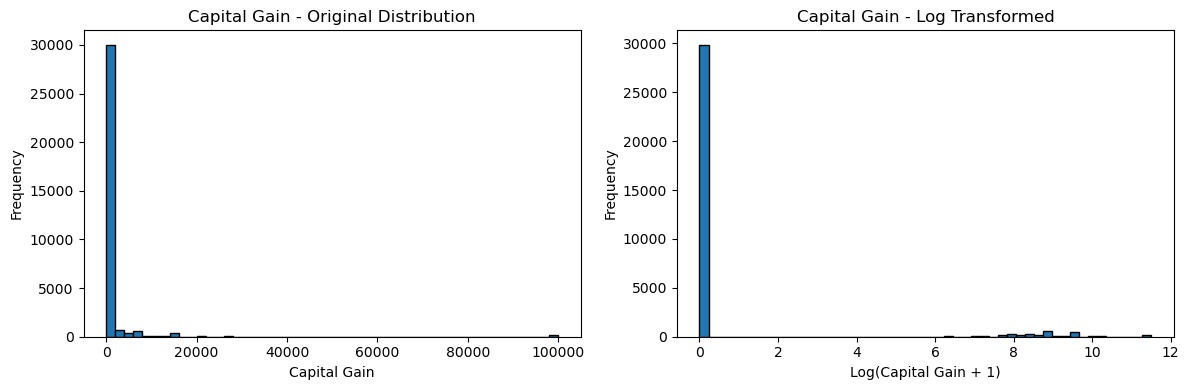


Skewness after log transformation: 3.10


In [12]:
# Check skewness of numerical features
print("Skewness of numerical features:")
for col in numerical_cols:
    skewness = df_clean[col].skew()
    print(f"{col}: {skewness:.2f}")

# capital_gain is highly skewed (most values are 0, with some large outliers)
# Apply log transformation
df_clean['capital_gain_log'] = np.log1p(df_clean['capital_gain'])  # log(1+x) handles zeros

# Visualize before and after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before transformation
axes[0].hist(df_clean['capital_gain'], bins=50, edgecolor='black')
axes[0].set_title('Capital Gain - Original Distribution')
axes[0].set_xlabel('Capital Gain')
axes[0].set_ylabel('Frequency')

# After transformation
axes[1].hist(df_clean['capital_gain_log'], bins=50, edgecolor='black')
axes[1].set_title('Capital Gain - Log Transformed')
axes[1].set_xlabel('Log(Capital Gain + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nSkewness after log transformation: {df_clean['capital_gain_log'].skew():.2f}")

## Justification for Log Transformation
Why log transformation for capital_gain:

Extreme skewness: The original skewness (~20-30) indicates severe positive skew

Zero-inflated data: Most people have 0 capital gains, with few having very high values

Model performance: Linear models and distance-based algorithms perform better with near-normal distributions

Outlier impact: Log transformation reduces the influence of extreme outliers

Interpretability: The transformation preserves the order while making the distribution more manageable

## Summary Statistics After Preprocessing

In [13]:
# Final summary
print("\n=== Final Preprocessing Summary ===")
print(f"Original dataset shape: {df.shape}")
print(f"After handling missing values: {df_clean.shape}")
print(f"After encoding (One-Hot + Label): {df_encoded.shape}")
print(f"\nNumerical features scaled: {len(numerical_cols)}")
print(f"New features created: 3 (age_group, capital_ratio, total_capital_impact)")
print(f"One-Hot encoded features: {len(low_cardinality_cols)}")
print(f"Label encoded features: {len(high_cardinality_cols)}")


=== Final Preprocessing Summary ===
Original dataset shape: (32561, 15)
After handling missing values: (32561, 19)
After encoding (One-Hot + Label): (32561, 15)

Numerical features scaled: 6
New features created: 3 (age_group, capital_ratio, total_capital_impact)
One-Hot encoded features: 1
Label encoded features: 7
